<a href="https://colab.research.google.com/github/Anika0502/Customer-Value-Lifetime-Project/blob/main/anika_tabassum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Customer Lifetime Value (CLV) with Recency, Frequency, Monetary (RFM) Features

**Goal.** Build a simple baseline model that predicts **3‑month Customer Lifetime Value (CLV)** from historical purchasing behavior using **RFM-style features**.

**Dataset.** Online Retail (transactional invoice line-items) loaded from a public Excel file.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: nicer printing
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)


## Part A — Load and inspect the data

**What to do:** Load the dataset into `df`, inspect basic structure, and answer the Part A questions.


In [ ]:


file_name = "https://raw.githubusercontent.com/rajeevratan84/datascienceforbusiness/master/OnlineRetail.xlsx"

# TODO A1: Load the Excel dataset into a DataFrame called `df`.
# YOUR CODE HERE
df = pd.read_excel(file_name)

In [ ]:
# TODO A2: Display the first 5 rows and the shape of df
# YOUR CODE HERE
display(df.head())
print(f"Shape of df: {df.shape}")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Shape of df: (541909, 8)


## Part B — Clean and prepare transactional features

**What to do:** Clean the raw transactions (remove returns/cancellations and missing customers), create `Sales`, then aggregate to an invoice-level table `orders_df`.


In [ ]:
# TODO B1: Remove quantities <= 0 (returns/cancellations) and rows with missing CustomerID.
# YOUR CODE HERE
df = df[df['Quantity'] > 0]
df = df[df['CustomerID'].notna()]

# TODO B2: Convert CustomerID to integer (or keep as string) consistently.
# YOUR CODE HERE
df['CustomerID'] = df['CustomerID'].astype(int)

# TODO B3: Print the date range in the dataset using InvoiceDate.
# YOUR CODE HERE
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

# TODO B4: Take all of the transactions that occurred before December 01, 2011.
# YOUR CODE HERE
df = df[df['InvoiceDate'] < '2011-12-01']

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [ ]:
# TODO B5: Create a `Sales` column as Quantity * UnitPrice
# YOUR CODE HERE
df['Sales'] = df['Quantity'] * df['UnitPrice']


In [ ]:
# TODO B6: Create `orders_df`, aggregated at the (CustomerID, InvoiceNo) level.
# It should contain:
#   - total Sales per invoice
#   - the latest InvoiceDate per invoice
# Name the columns exactly: 'Sales' and 'InvoiceDate'
#
# Hint: use groupby(['CustomerID','InvoiceNo']).agg(...)

# YOUR CODE HERE
orders_df = (
    df.groupby(['CustomerID', 'InvoiceNo'])
    .agg(
        Sales=('Sales', 'sum'),
        InvoiceDate=('InvoiceDate', 'max')
    )
    .reset_index()
)

📝 **Questions (Part B)**  
1. Why might we remove negative/zero quantities when modeling CLV?  
2. Why aggregate to (CustomerID, InvoiceNo) before creating customer-level features?  


## Part C — Customer-level summary statistics (baseline exploration)

**What to do:** Implement helper functions, then build `summary_df` with customer-level behavior features (min/max/sum/avg/count of Sales and purchase timing features).


In [ ]:
# TODO C1: Complete the helper functions below.

def groupby_mean(x):
    return x.mean()

def groupby_count(x):
    return x.count()

def purchase_duration(x):
    """Return the number of days between a customer's first and last purchase date."""
    # YOUR CODE HERE
    return (x.max() - x.min()).days

def avg_frequency(x):
    """Return the average days between purchases (avoid divide-by-zero)."""
    # YOUR CODE HERE
    if x.count() > 1:
      return (x.max() - x.min()).days / (x.count() - 1)
    return 0

# naming makes resulting columns nicer after groupby
groupby_mean.__name__ = "avg"
groupby_count.__name__ = "count"
purchase_duration.__name__ = "purchase_duration"
avg_frequency.__name__ = "purchase_frequency"


In [ ]:
# TODO C2: Build `summary_df` at the customer level from orders_df.
# Required aggregations:
# - For Sales: min, max, sum, average, count
# - For InvoiceDate: min, max, purchase_duration, purchase_frequency
#

# YOUR CODE HERE (fill the aggregation dictionary)
agg_dict = {
    'Sales': [min, max, 'sum', groupby_mean, groupby_count],
    'InvoiceDate': [min, max, purchase_duration, avg_frequency],
}

summary_df = (
    orders_df
    .reset_index()
    .groupby('CustomerID')
    .agg(agg_dict)
)

# Then flatten multi-index columns:
summary_df.columns = ['_'.join(col).lower() for col in summary_df.columns]

# Display results
display(summary_df.head())


/tmp/ipython-input-3422873076.py:17: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  .agg(agg_dict)
/tmp/ipython-input-3422873076.py:17: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  .agg(agg_dict)


,sales_min,sales_max,sales_sum,sales_avg,sales_count,invoicedate_min,invoicedate_max,invoicedate_purchase_duration,invoicedate_purchase_frequency
CustomerID,,,,,,,,,
12346,77183.60,77183.60,77183.60,77183.600000,1,2011-01-18 10:01:00,2011-01-18 10:01:00,0,0.0
12347,382.52,1294.32,4085.18,680.863333,6,2010-12-07 14:57:00,2011-10-31 12:25:00,327,65.4
12348,227.44,892.80,1797.24,449.310000,4,2010-12-16 19:09:00,2011-09-25 13:13:00,282,94.0
12349,1757.55,1757.55,1757.55,1757.550000,1,2011-11-21 09:51:00,2011-11-21 09:51:00,0,0.0
12350,334.40,334.40,334.40,334.400000,1,2011-02-02 16:01:00,2011-02-02 16:01:00,0,0.0


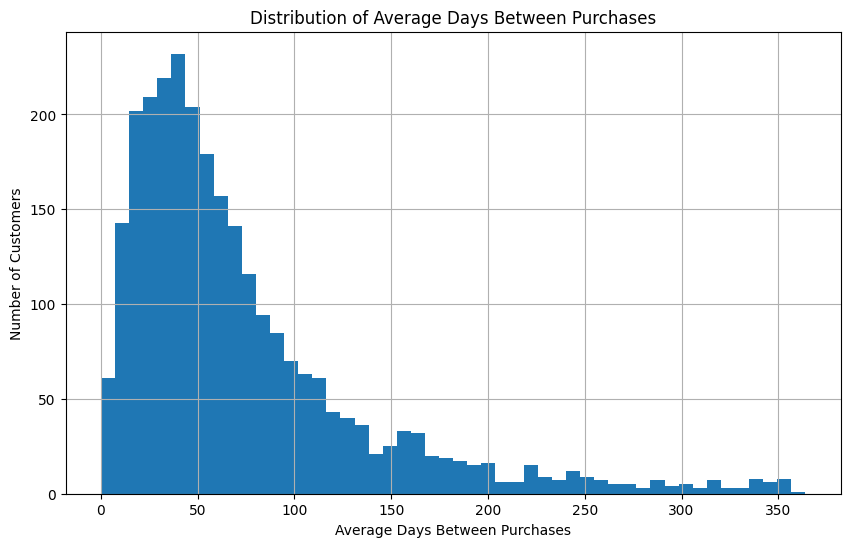

In [ ]:
# TODO C3: Create a histogram of `invoicedate_purchase_frequency` (or the equivalent column you created).
# - Filter out customers with purchase_duration <= 0 before plotting.
# - Label axes and title.

# YOUR CODE HERE
summary_df_filtered = summary_df[summary_df['invoicedate_purchase_duration'] > 0]

plt.figure(figsize=(10, 6))
summary_df_filtered['invoicedate_purchase_frequency'].hist(bins=50)
plt.title('Distribution of Average Days Between Purchases')
plt.xlabel('Average Days Between Purchases')
plt.ylabel('Number of Customers')
plt.show()


📝 **Questions (Part C)**  
1. What does **purchase_duration** tell you about customer behavior?  
2. Describe the histogram shape (e.g., skewed left/right). What does that imply?  
3. Identify one potential outlier issue you see and how you would handle it.  


## Part D — Create a 3‑month CLV prediction dataset

**What to do:** Split time into 3‑month windows and create a month-bucket index `M` (e.g., `M_1` is most recent). This sets up the supervised learning problem: use past windows to predict the next window.


In [ ]:
# We will predict CLV for a given 3-month window using features from prior windows.

# Set the frequency string for 3 months.
clv_freq = "3M"

# TODO D1: Create `data_df` that aggregates orders_df into 3-month periods per customer.
# Group keys: CustomerID and InvoiceDate bucketed into 3-month windows using pd.Grouper.
# Aggregate Sales with: sum, mean, count
#
# Hint (template):
# data_df = orders_df.reset_index().groupby([...]).agg({...})
# Hint: After .agg(...), flatten multi-index columns, reset_index(), and display head.

# YOUR CODE HERE
data_df = (
    orders_df.groupby(['CustomerID', pd.Grouper(key='InvoiceDate', freq=clv_freq)])
    .agg(
        sales_sum=('Sales', 'sum'),
        sales_avg=('Sales', 'mean'),
        sales_count=('Sales', 'count')
    )
    .reset_index()
)
display(data_df.head())

/tmp/ipython-input-2328328955.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  orders_df.groupby(['CustomerID', pd.Grouper(key='InvoiceDate', freq=clv_freq)])


,CustomerID,InvoiceDate,sales_sum,sales_avg,sales_count
0,12346,2011-03-31,77183.60,77183.600,1
1,12347,2010-12-31,711.79,711.790,1
2,12347,2011-03-31,475.39,475.390,1
3,12347,2011-06-30,1018.77,509.385,2
4,12347,2011-09-30,584.91,584.910,1


In [ ]:
# TODO D2: Create a recency-like month index column `M`.
# Idea: sort unique 3-month period start dates (InvoiceDate) in descending order,
# and map the most recent period to 'M_1', next to 'M_2', etc.
#
# Steps:
# 1) Extract the unique period start dates from data_df['InvoiceDate']
# 2) Sort them from most recent → oldest
# 3) Create labels "M_1", "M_2", ...
# 4) Build a mapping dict (date → label) and use it to create data_df['M']
# 5) Show data_df[['CustomerID','InvoiceDate','M']].head()
#
# YOUR CODE HERE

# 1) Extract unique period start dates
unique_periods = data_df['InvoiceDate'].unique()

# 2) Sort them from most recent → oldest
unique_periods = pd.Series(unique_periods).sort_values(ascending=False)

# 3) Create labels "M_1", "M_2", ...
periods_labels = [f"M_{i+1}" for i in range(len(unique_periods))]

#4) Build a mapping dict (date → label) and use it to create data_df['M']
period_mapping = dict(zip(unique_periods, periods_labels))
data_df['M'] = data_df['InvoiceDate'].map(period_mapping)

# 5) Show data_df[['CustomerID','InvoiceDate','M']].head()
display(data_df[['CustomerID', 'InvoiceDate', 'M']].head())




,CustomerID,InvoiceDate,M
0,12346,2011-03-31,M_4
1,12347,2010-12-31,M_5
2,12347,2011-03-31,M_4
3,12347,2011-06-30,M_3
4,12347,2011-09-30,M_2


📝 **Questions (Part D)**  
1. Why is this mapping useful for building supervised learning targets (X → y)?  


## Part E — Build RFM-style features and the CLV target

**What to do:** Create `features_df` (past-window features) and `response_df` (target CLV for the most recent window), then merge into `sample_set_df`.


In [ ]:
# TODO E1: Create `features_df` using a pivot table.
# Use only rows where M != 'M_1' as features (history), and pivot months into columns.
#
# Required:
# - index: CustomerID
# - columns: M
# - values: sales_sum, sales_avg, sales_count
#
# Steps:
# 1) Filter data_df to keep only historical months (exclude 'M_1')
# 2) Build a pivot table with index=CustomerID, columns=M, values=[...]
# 3) Flatten the multi-index columns into single strings (e.g., sales_sum_M_2)
# 4) Display features_df.head()
#
# YOUR CODE HERE
# 1) Filter data_df to keep only historical months (exclude 'M_1')
historical_data = data_df[data_df['M'] != 'M_1']

# 2) Build a pivot table with index=CustomerID, columns=M, values=[...]
features_df = historical_data.pivot_table(
    index='CustomerID',
    columns='M',
    values=['sales_sum', 'sales_avg', 'sales_count']

)
# 3) Flatten the multi-index columns into single strings (e.g., sales_sum_M_2)
features_df.columns = [f'{val}_{col}' for val, col in features_df.columns]
# 4) Display features_df.head()
display(features_df.head())

,sales_avg_M_2,sales_avg_M_3,sales_avg_M_4,sales_avg_M_5,sales_count_M_2,sales_count_M_3,sales_count_M_4,sales_count_M_5,sales_sum_M_2,sales_sum_M_3,sales_sum_M_4,sales_sum_M_5
CustomerID,,,,,,,,,,,,
12346,NaN,NaN,77183.600,NaN,NaN,NaN,1.0,NaN,NaN,NaN,77183.60,NaN
12347,584.91,509.385,475.390,711.79,1.0,2.0,1.0,1.0,584.91,1018.77,475.39,711.79
12348,310.00,367.000,227.440,892.80,1.0,1.0,1.0,1.0,310.00,367.00,227.44,892.80
12350,NaN,NaN,334.400,NaN,NaN,NaN,1.0,NaN,NaN,NaN,334.40,NaN
12352,316.25,NaN,312.362,NaN,2.0,NaN,5.0,NaN,632.50,NaN,1561.81,NaN


In [ ]:
# TODO E2: Create `response_df` for the target CLV in the most recent month bucket (M_1).
# Keep only: CustomerID and sales_sum
# Rename sales_sum to: 'CLV_'+clv_freq (e.g., CLV_3M)
#
# Steps:
# 1) Filter data_df to rows where M == 'M_1'
# 2) Select only the columns: CustomerID and sales_sum
# 3) Rename sales_sum to f"CLV_{clv_freq}"
# 4) Display response_df.head()
#
# YOUR CODE HERE
# Steps:
# 1) Filter data_df to rows where M == 'M_1'
response_df = data_df[data_df['M'] == 'M_1'].copy()

# 2) Select only the columns: CustomerID and sales_sum
response_df = response_df[['CustomerID', 'sales_sum']]

# 3) Rename sales_sum to f"CLV_{clv_freq}"
response_df.rename(columns={'sales_sum': f'CLV_{clv_freq}'}, inplace=True)

# 4) Display response_df.head()
display(response_df.head())

,CustomerID,CLV_3M
5,12347,1294.32
10,12349,1757.55
14,12352,311.73
20,12356,58.35
21,12357,6207.67


In [ ]:
# TODO E3: Merge features and response into `sample_set_df`.
# - Merge features_df (left) with response_df on CustomerID
# - Fill missing values with 0
#
# Steps:
# 1) Merge features_df (as the left table) with response_df using CustomerID
# 2) Fill missing values with 0
# 3) Display sample_set_df.head()
#
# YOUR CODE HERE
# Steps:
# 1) Merge features_df (as the left table) with response_df using CustomerID
sample_set_df = features_df.merge(response_df, on='CustomerID', how='left')

# 2) Fill missing values with 0
sample_set_df.fillna(0, inplace=True)

# 3) Display sample_set_df.head()
display(sample_set_df.head())

,CustomerID,sales_avg_M_2,sales_avg_M_3,sales_avg_M_4,sales_avg_M_5,sales_count_M_2,sales_count_M_3,sales_count_M_4,sales_count_M_5,sales_sum_M_2,sales_sum_M_3,sales_sum_M_4,sales_sum_M_5,CLV_3M
0,12346,0.00,0.000,77183.600,0.00,0.0,0.0,1.0,0.0,0.00,0.00,77183.60,0.00,0.00
1,12347,584.91,509.385,475.390,711.79,1.0,2.0,1.0,1.0,584.91,1018.77,475.39,711.79,1294.32
2,12348,310.00,367.000,227.440,892.80,1.0,1.0,1.0,1.0,310.00,367.00,227.44,892.80,0.00
3,12350,0.00,0.000,334.400,0.00,0.0,0.0,1.0,0.0,0.00,0.00,334.40,0.00,0.00
4,12352,316.25,0.000,312.362,0.00,2.0,0.0,5.0,0.0,632.50,0.00,1561.81,0.00,311.73


📝 **Questions (Part E)**  
1. Explain why we exclude **M_1** from the feature set.  
2. What does a missing value (NaN) in a pivoted feature column usually mean here?  


## Part F — Train a baseline regression model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, median_absolute_error

# Target variable name
target_var = 'CLV_' + clv_freq

# TODO F1: Build the feature list `all_features` (exclude CustomerID and target_var).
#
# Steps:
# 1) Start from the list of columns in sample_set_df
# 2) Exclude the identifier column (CustomerID)
# 3) Exclude the target column (target_var)
#
# YOUR CODE HERE
all_features = [col for col in sample_set_df.columns if col not in ['CustomerID', target_var]]


# TODO F2: Split into train/test (30% test), using train_test_split.
#
# Steps:
# 1) Create X using the feature columns (all_features)
# 2) Create y using the target column (target_var)
# 3) Split into training and testing sets (30% test)
# 4) Use a fixed random_state for reproducibility
#
# YOUR CODE HERE
# Steps:
# 1) Create X using the feature columns (all_features)
X = sample_set_df[all_features]
# 2) Create y using the target column (target_var)
y = sample_set_df[target_var]
# 3) Split into training and testing sets (30% test)
# 4) Use a fixed random_state for reproducibility
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# TODO F3: Fit a LinearRegression model named `reg_fit`.
#
# Steps:
# 1) Create the LinearRegression model object
# 2) Fit the model on the training data
#
# YOUR CODE HERE
# Steps:
# 1) Create the LinearRegression model object
reg_fit = LinearRegression()

# 2) Fit the model on the training data
reg_fit.fit(X_train, y_train)

LinearRegression()

In [ ]:
# TODO F4: Create predictions on train and test sets: train_preds, test_preds
# YOUR CODE HERE
train_preds = reg_fit.predict(X_train)
test_preds = reg_fit.predict(X_test)

# TODO F5: Print in-sample and out-of-sample Mean Squared Error (MSE).
# YOUR CODE HERE
from sklearn.metrics import mean_squared_error

in_sample_mse = mean_squared_error(y_train, train_preds)
out_of_sample_mse = mean_squared_error(y_test, test_preds)

print(f"In-sample MSE: {in_sample_mse:.2f}")
print(f"Out-of-sample MSE: {out_of_sample_mse:.2f}")

In-sample MSE: 1676505.46
Out-of-sample MSE: 4510669.26


In [ ]:
# TODO F6: Create a DataFrame `coef` with columns ['feature','coef'] for the learned coefficients.
#
# Steps:
# 1) Get the list of feature names (all_features)
# 2) Get the fitted model coefficients (from your trained LinearRegression model)
# 3) Build a DataFrame with columns: feature, coef
# 4) Sort by coef (descending) and show the top 10
#
# YOUR CODE HERE
coef = pd.DataFrame({
    'feature': all_features,
    'coef': reg_fit.coef_

})
coef = coef.sort_values(by='coef', ascending=False)
display(coef.head(10))

,feature,coef
5,sales_count_M_3,54.483496
7,sales_count_M_5,21.259005
8,sales_sum_M_2,0.711509
11,sales_sum_M_5,0.473114
2,sales_avg_M_4,0.418982
10,sales_sum_M_4,0.117931
9,sales_sum_M_3,0.061988
1,sales_avg_M_3,-0.238261
0,sales_avg_M_2,-0.410263
3,sales_avg_M_5,-0.442104


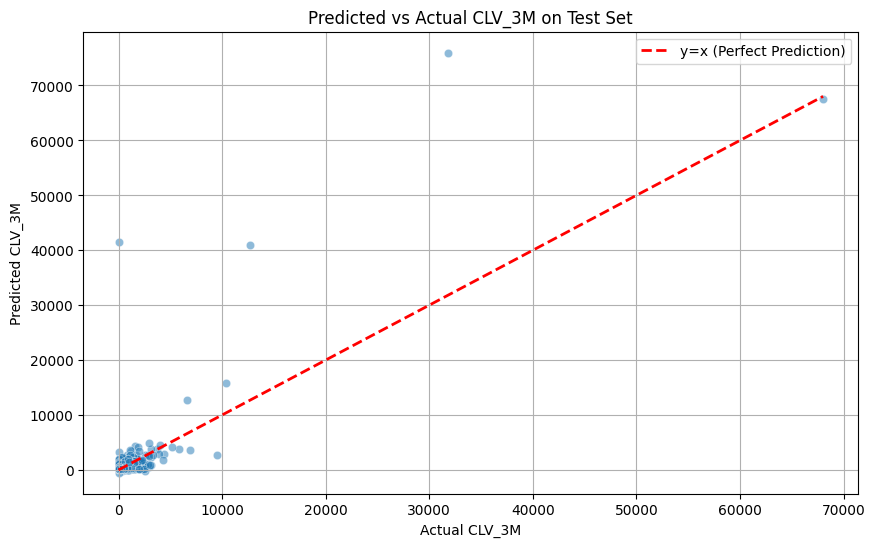

In [ ]:
# TODO F7: Plot predicted vs actual CLV on the TEST set (scatter plot).
# Include a y=x reference line.
# Label axes and title.

import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=test_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y=x (Perfect Prediction)')
plt.xlabel(f'Actual {target_var}')
plt.ylabel(f'Predicted {target_var}')
plt.title(f'Predicted vs Actual {target_var} on Test Set')
plt.legend()
plt.grid(True)
plt.show()


📝 **Questions (Part F)**  
1. Compare in-sample vs out-of-sample metrics.
2. Pick the **top 3 positive** coefficients and interpret what they mean in business terms.  
3. If the model performs poorly, list feature negineering improvements?

